In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


books_backup = pd.read_csv('Books_catalog')
display(books_backup)


,Title,Price,Availability,Rate
0,A Light in the Attic,Â£51.77,In stock,Three
1,Tipping the Velvet,Â£53.74,In stock,One
2,Soumission,Â£50.10,In stock,One
3,Sharp Objects,Â£47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,Five
...,...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,Â£55.53,In stock,One
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",Â£57.06,In stock,Four
997,A Spy's Devotion (The Regency Spies of London #1),Â£16.97,In stock,Five
998,1st to Die (Women's Murder Club #1),Â£53.98,In stock,One


In [23]:
# Cleaning Data

books_df = books_backup.copy()

books_df['Volume'] = books_df['Title'].str.extract(r'(?:#|Vol\.)\s*(\d+)')
books_df['Volume'] = pd.to_numeric(books_df['Volume'], errors='coerce').fillna(1).astype(int)

books_df['Price'] = books_df['Price'].str.replace('Â£', '').str.strip().astype(float)


books_df['Title'] = (
    books_df['Title']
    .str.replace(r'#\d+', '', regex=True)
    .str.replace(r'Vol.\d+', '', regex=True)
    .str.strip()
    .str.replace(r'[-–—,._]$', '', regex=True)
    .str.strip()
    .str.replace('#', '')
)

books_df['Rate'] = (
    books_df['Rate']
    .str.replace('One', '1')
    .str.replace('Two', '2')
    .str.replace('Three', '3')
    .str.replace('Four', '4')
    .str.replace('Five', '5')
    .astype(int)
    )

#books_df.info()
display(books_df[['Title', 'Volume', 'Price', 'Rate']])

,Title,Volume,Price,Rate
0,A Light in the Attic,1,51.77,3
1,Tipping the Velvet,1,53.74,1
2,Soumission,1,50.10,1
3,Sharp Objects,1,47.82,4
4,Sapiens: A Brief History of Humankind,1,54.23,5
...,...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,1,55.53,1
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human )",1,57.06,4
997,A Spy's Devotion (The Regency Spies of London ),1,16.97,5
998,1st to Die (Women's Murder Club ),1,53.98,1


In [31]:
# Insights

mean = books_df['Price'].mean()
median = books_df['Price'].median()
min_value = books_df['Price'].min()
max_value = books_df['Price'].max()
amplitude = max_value - min_value

rates_qtd = books_df.groupby('Rate')['Volume'].count().sort_values(ascending=False).reset_index(name='quantity')
rates_price = books_df.groupby('Rate')['Price'].mean().round(2).sort_values(ascending=False).reset_index(name='mean')

top10_five = books_df[books_df['Rate']==5].sort_values(['Price'], ascending=False).head(10)
top10_lowprice = books_df.sort_values(['Price']).head(10)

# print(mean)
# print(median)
# print(min_value)
# print(max_value)
# print(amplitude)
display(rates_qtd)
display(rates_price)
display(top10_five)
display(top10_lowprice)



,Rate,quantity
0,1,226
1,3,203
2,2,196
3,5,196
4,4,179


,Rate,mean
0,4,36.09
1,5,35.37
2,2,34.81
3,3,34.69
4,1,34.56


,Title,Price,Availability,Rate,Volume
560,The Barefoot Contessa Cookbook,59.92,In stock,5,1
812,Life Without a Recipe,59.04,In stock,5,1
637,Approval Junkie: Adventures in Caring Too Much,58.81,In stock,5,1
379,How to Speak Golf: An Illustrated Guide to Lin...,58.32,In stock,5,1
631,Digital Fortress,58.00,In stock,5,1
545,The Sound Of Love,57.84,In stock,5,1
910,Travels with Charley: In Search of America,57.82,In stock,5,1
309,El Deafo,57.62,In stock,5,1
898,H is for Hawk,57.42,In stock,5,1
100,Immunity: How Elie Metchnikoff Changed the Cou...,57.36,In stock,5,1


,Title,Price,Availability,Rate,Volume
638,An Abundance of Katherines,10.00,In stock,5,1
501,The Origin of Species,10.01,In stock,4,1
716,The Tipping Point: How Little Things Can Make ...,10.02,In stock,2,1
84,Patience,10.16,In stock,3,1
302,Greek Mythic History,10.23,In stock,5,1
558,The Fellowship of the Ring (The Lord of the Ri...,10.27,In stock,2,1
479,History of Beauty,10.29,In stock,4,1
242,The Lucifer Effect: Understanding How Good Peo...,10.40,In stock,1,1
434,"NaNo What Now? Finding your editing process, r...",10.41,In stock,4,1
274,Pet Sematary,10.56,In stock,3,1


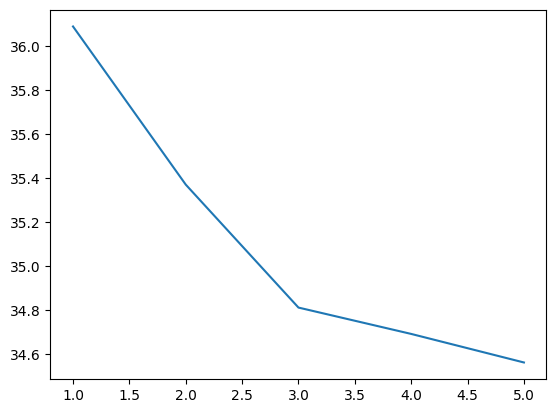

In [ ]:
# Graphics

rates = list(rates_price['Rate'].sort_values())
means = list(rates_price['mean'])
fig, ax = plt.subplots()
ax.plot(rates,means)

rates_qtd.columns = ['Nota'], rates_qtd
